正在读取全市场数据，请稍候...
正在过滤沪深主板数据...
正在构建股票历史数据高速缓存...
开始按周执行【筹码峰突破 + 小市值低价股】调仓模拟...

✅ 交易明细已成功导出至: F:\self_quant\quant\回测excel\筹码峰突破_小市值低价轮动明细.xlsx
💰 初始本金: 50,000.00 元
💰 最终总资产: 9,821.05 元
📈 策略总收益率: -80.36%


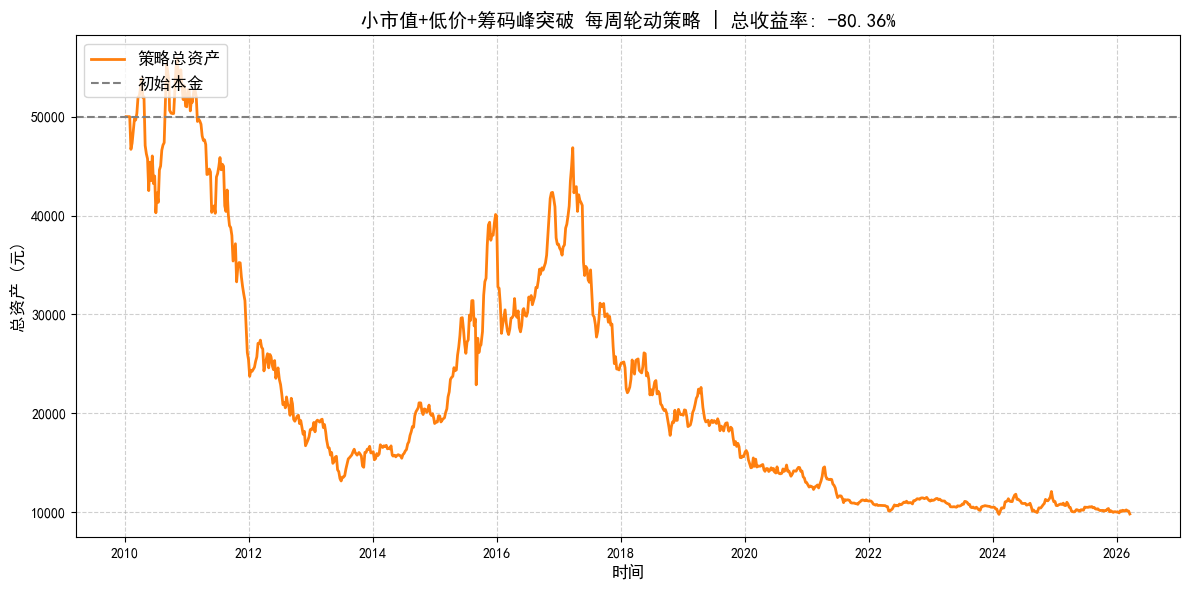

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore') # 忽略一些不影响计算的 Pandas 警告

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\quant\回测excel\筹码峰突破_小市值低价轮动明细.xlsx"

INITIAL_CASH = 50000.0  # 初始本金 5万元
TARGET_STOCK_NUM = 10   # 目标持仓 10 只

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤沪深主板股票
print("正在过滤沪深主板数据...")
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

df.sort_values(by=['date', 'code'], inplace=True)

# 提取每周的最后一个交易日作为调仓日
df['year_week'] = df['date'].dt.to_period('W')
trade_dates = df.groupby('year_week')['date'].max().sort_values().tolist()

# ==========================================
# 新增：筹码分布计算核心函数 (带换手率时间衰减)
# ==========================================
def calculate_chip_poc(df_hist, bins=50):
    """计算核心筹码峰(POC)价格"""
    if len(df_hist) < 20:
        return np.nan # 数据不足

    closes = df_hist['close'].values
    volumes = df_hist['volume'].values
    # 确保换手率是小数比例 (假设原数据 1.5 代表 1.5%)
    turnovers = df_hist['turn'].values / 100.0

    min_price = closes.min() * 0.95
    max_price = closes.max() * 1.05
    if min_price == max_price: return closes[0]

    price_bins = np.linspace(min_price, max_price, bins)
    cost_dist = np.zeros(bins - 1)

    for i in range(len(closes)):
        # 换手率封顶 0.99，防止数据异常导致衰减归零
        t = min(turnovers[i], 0.99)
        # 老筹码衰减
        cost_dist *= (1 - t)

        # 新筹码注入
        bin_idx = np.digitize(closes[i], price_bins) - 1
        if bin_idx >= len(cost_dist): bin_idx = len(cost_dist) - 1
        if bin_idx < 0: bin_idx = 0
        cost_dist[bin_idx] += volumes[i]

    # 找到成交量最大的价格区间，取中值
    max_idx = np.argmax(cost_dist)
    poc_price = (price_bins[max_idx] + price_bins[max_idx + 1]) / 2
    return poc_price

# 【算力优化】提前构建按股票代码分组的历史数据字典，查询速度提升上百倍
print("正在构建股票历史数据高速缓存...")
df.sort_values(by=['code', 'date'], inplace=True)
grouped_by_code = {code: group for code, group in df.groupby('code')}

# 恢复按日期排序以供主循环使用
df.sort_values(by=['date', 'code'], inplace=True)

# ==========================================
# 第二步：定义交易费率计算函数
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    total_fee = commission + transfer_fee + stamp_duty
    return total_fee, amount

# ==========================================
# 第三步：账户类与回测主引擎
# ==========================================
class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_date, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            price = current_prices_dict.get(code, pos['price'])
            self.positions[code]['price'] = price
            stock_value += pos['volume'] * price
        return self.cash + stock_value

account = Account(INITIAL_CASH)

print("开始按周执行【筹码峰突破 + 小市值低价股】调仓模拟...")

for date in trade_dates:
    daily_data = df[df['date'] == date].set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(date, current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- 选股逻辑 ----------------
    valid_pool = daily_data[(daily_data['tradestatus'] == 1) &
                            (daily_data['isST'] == 0) &
                            (daily_data['peTTM'] > 0)&(daily_data['pbMRQ']>0)].copy()

    target_codes = []
    if len(valid_pool) >= 50:
        # 1. 放宽初筛范围：先选出市值最小的 100 只股票
        smallest_100 = valid_pool.sort_values(by='流通市值', ascending=True).head(100)

        qualified_stocks = []
        # 2. 筹码峰突破过滤
        for code in smallest_100.index:
            hist_df = grouped_by_code.get(code)
            if hist_df is None: continue

            # 截取该股票过去半年的数据（120个交易日）计算筹码分布
            sub_hist = hist_df[hist_df['date'] <= date].tail(120)
            poc = calculate_chip_poc(sub_hist)

            if pd.isna(poc): continue

            current_close = current_prices[code]
            # 【突破逻辑】：收盘价刚好大于筹码峰，且涨出幅度不超过5% (刚刚突破)
            if 1.00 < (current_close / poc) <= 1.05:
                qualified_stocks.append(code)

        # 3. 在符合筹码突破的微盘股中，选出价格最低的 10 只
        if len(qualified_stocks) > 0:
            target_codes = smallest_100.loc[qualified_stocks].sort_values(by='close', ascending=True).head(TARGET_STOCK_NUM).index.tolist()

    # ---------------- 卖出逻辑 ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code not in daily_data.index:
            lost_vol = account.positions[code]['volume']
            last_price = account.positions[code]['price']
            loss_amount = lost_vol * last_price
            del account.positions[code]
            account.trade_logs.append({
                '日期': date, '股票代码': code, '买卖方向': '强制清理(退市)',
                '成交价': 0, '成交股数': lost_vol, '成交金额': 0, '交易费': 0,
                '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                '备注': f'数据缺失/退市，市值计提全额亏损 {round(loss_amount, 2)}元',
                '当前实仓股票': ", ".join(list(account.positions.keys()))
            })
            continue

        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)

            if is_trading and pct_chg > -9.3:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)

                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': '常规换仓卖出',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })
            elif not is_trading:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(停牌/退市)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': '停牌或无交易数据，强制保留',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })
            elif pct_chg <= -9.3:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(跌停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'跌幅 {pct_chg:.2f}% 封死跌停',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })

    # ---------------- 买入逻辑 ----------------
    stocks_to_buy = [code for code in target_codes if code not in account.positions]

    current_pos_count = len(account.positions)
    free_slots = max(0, TARGET_STOCK_NUM - current_pos_count)
    actual_stocks_to_buy = stocks_to_buy[:free_slots]

    if len(actual_stocks_to_buy) > 0:
        target_cash_per_stock = account.cash / len(actual_stocks_to_buy)

        for code in actual_stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            is_st = st_dict.get(code, 0) == 1

            if is_trading and not is_st and pct_chg < 9.3:
                buy_price = current_prices[code]
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)
                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入',
                            '成交价': buy_price, '成交股数': buy_vol,
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                            '备注': '筹码峰突破买入',
                            '当前实仓股票': ", ".join(list(account.positions.keys()))
                        })
            elif pct_chg >= 9.3:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '买入失败(涨停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'涨幅 {pct_chg:.2f}% 封死涨停',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })

# ==========================================
# 第四步：输出结果与可视化
# ==========================================
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n✅ 交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

# 绘制收益曲线
plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#ff7f0e', linewidth=2, label='策略总资产')
plt.title(f'小市值+低价+筹码峰突破 每周轮动策略 | 总收益率: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()